In [84]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Summary
- tx = np.c_[np.ones(num_samples), x] --> convert 1D feaure vector 'x' to 2D with 1s in first col as bias terms
  - **np.c_**[vector1, vector2] --> stacks arrays column-wise
  - e.g, vector1 = [1,1], vector2 = [183, 169], then output:\
        [[1  183]\
        [1   169 ]]
- 

# Load the data

In [85]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False) # input feature(x): height, output(y): weight
x, mean_x, std_x = standardize(height) # x: input training data samples or featues --> feature vector , y: output
y, tx = build_model_data(x, weight) # tx = simply 'x' with added 1s bias term included in the matrix

In [86]:
print("y: ",y.shape, "\n\ntx: ",tx.shape)
print("\n", tx) # heights 'x' with 1s as bias in first col --> 2D feature matrix now (N x 2)


y:  (10000,) 

tx:  (10000, 2)

 [[ 1.          1.94406149]
 [ 1.          0.62753668]
 [ 1.          2.01244346]
 ...
 [ 1.         -0.64968792]
 [ 1.          0.69312469]
 [ 1.         -1.14970831]]


### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [87]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    
    N = tx.shape[0] # total data samples
    e = y - (tx @ w) # error vector
    
    mse = (1/(2*N)) * np.sum(e**2, axis=0) # NOTE: its just a convention to have "1/2" in MSE. When you take gradient of MSE to during GD, 2 comes out in front & that 1/2 cancles it, making gradient expression cleaner.
    # mse = 1/2 * np.mean(e**2) # same as above. 'e' is a vector, np.mean simply finds mean (scalar) of all its vals

    mae = (1/N) * np.sum(np.abs(e), axis=0)
    # mae = np.mean(np.abs(e))

    #print("mse:", mse)
    #print("mae:", mae)
    return mse
    

w = np.array([1,2]) # for testing
compute_loss(y, tx, w)

2694.4833658870843

# 2. Grid Search

Fill in the function `grid_search()` below:

In [88]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))

    for i, w0 in enumerate(grid_w0):
        for j, w1 in enumerate(grid_w1):
            w = np.array([w0, w1])
            losses[i, j] = compute_loss(y, tx, w)
    
    return losses


Let us play with the grid search demo now!

Grid Search: loss*=42.42448314678248, w0*=66.66666666666669, w1*=16.666666666666686, execution time=0.007 seconds


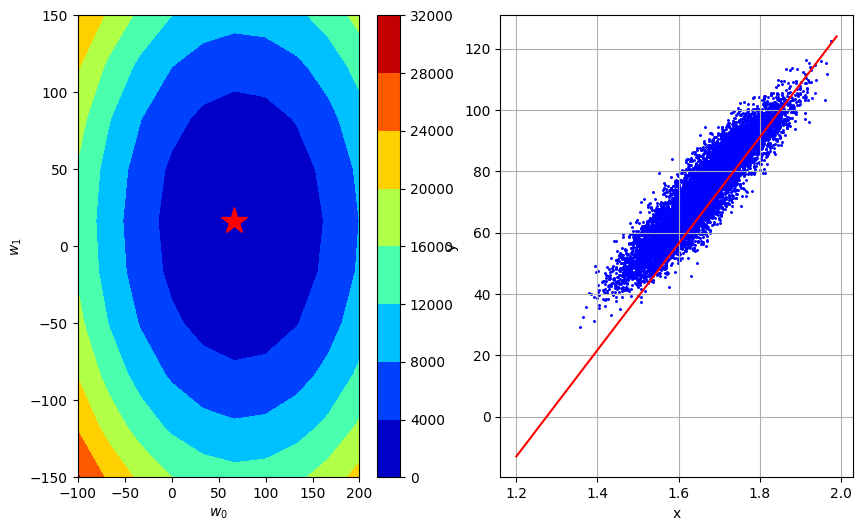

In [89]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=10)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
#fig.savefig("grid_plot")  # Optional saving

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [90]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    N = tx.shape[0] # no. of input samples
    err = y - (tx @ w) # error vector
    grad = (-1/N) * (tx.T @ err) # gradient
    return grad, err # also returning 'e' anyways for printing loss w/o computing again

w = np.array([100,20]) # ex3 (b) [i] --> w0=100, w1=20
grad, _ = compute_gradient(y, tx, w)
print(f"w:{w}\ngrad:{grad}")

w = np.array([50,10]) # ex3 (b) [ii] --> w0=50, w1=10
grad, _ = compute_gradient(y, tx, w)
print(f"\nw:{w}\ngrad:{grad}")

w:[100  20]
grad:[26.706078    6.52028757]

w:[50 10]
grad:[-23.293922    -3.47971243]


Please fill in the functions `gradient_descent` below:

In [91]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        
        grad, e = compute_gradient(y, tx, w)
        loss = 1/2 * np.mean(e**2) # MSE
        w = w - gamma*grad

        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [92]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/499: loss=2792.2367127591674, w0=51.30574540147368, w1=9.435798704492349
GD iter. 1/499: loss=265.3024621089587, w0=66.69746902191575, w1=12.26653831584002
GD iter. 2/499: loss=37.87837955044096, w0=71.31498610804836, w1=13.115760199244335
GD iter. 3/499: loss=17.41021212017444, w0=72.70024123388815, w1=13.370526764265632
GD iter. 4/499: loss=15.568077051450448, w0=73.11581777164008, w1=13.446956733772025
GD iter. 5/499: loss=15.402284895265295, w0=73.24049073296565, w1=13.469885724623941
GD iter. 6/499: loss=15.38736360120863, w0=73.27789262136334, w1=13.476764421879516
GD iter. 7/499: loss=15.38602068474353, w0=73.28911318788263, w1=13.478828031056189
GD iter. 8/499: loss=15.385899822261674, w0=73.29247935783842, w1=13.47944711380919
GD iter. 9/499: loss=15.385888944638305, w0=73.29348920882515, w1=13.47963283863509
GD iter. 10/499: loss=15.3858879656522, w0=73.29379216412117, w1=13.479688556082861
GD iter. 11/499: loss=15.385887877543452, w0=73.29388305071, w1=13.47970527

interactive(children=(IntSlider(value=499, description='n_iter', max=500, min=499), Output()), _dom_classes=('…

<function __main__.plot_figure(n_iter)>

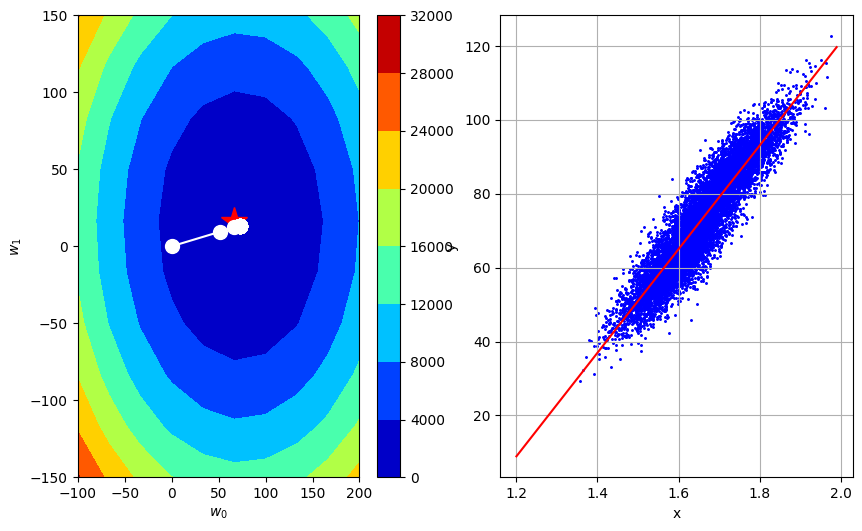

In [93]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


#interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))
interact(plot_figure, n_iter=IntSlider(min=499, max=500))

# 4. Stochastic gradient descent

In [94]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """
    # NOTE: It's exactly the same as usual gradient :)
    B = tx.shape[0] # no. of input samples ('B' instead of 'N' just to show its batchsize and not full data)
    err = y - (tx @ w) # error vector
    grad = (-1/B) * (tx.T @ err) # gradient
    return grad, err # also returning 'e' anyways for printing loss w/o computing again

def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # get a single random batch. NOTE: batch_iter() is made using 'yield' so you have to use it as an iterator in loop even to run it once.
        for y_batch, tx_batch in batch_iter(y, tx, batch_size, num_batches=1, shuffle= True): 
            grad, e = compute_stoch_gradient(y_batch, tx_batch, w)
            loss = 1/2 * np.mean(e**2) # MSE
            w = w - gamma*grad
            # store w and loss
            ws.append(w)
            losses.append(loss)
        # above loops runs once to get a single batch, batch_iter() is designed to work this way

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [95]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=3651.132143042074, w0=8.545328715786274, w1=2.924672338617837
SGD iter. 1/49: loss=1747.3045887004985, w0=14.456850666520278, w1=-1.6476721486439354
SGD iter. 2/49: loss=1184.0200523714611, w0=19.323101897953897, w1=-6.655718955951129
SGD iter. 3/49: loss=4059.360861318218, w0=28.333496851914816, w1=11.351477171695613
SGD iter. 4/49: loss=678.7592486387771, w0=32.017948639192745, w1=7.0787276094164495
SGD iter. 5/49: loss=1532.2969269693776, w0=37.55382603481736, w1=17.192632841067834
SGD iter. 6/49: loss=341.5010176027717, w0=40.16725679763765, w1=20.24372254769273
SGD iter. 7/49: loss=754.6715644445751, w0=44.052283346953814, w1=21.020457533879224
SGD iter. 8/49: loss=553.0821658485123, w0=47.378188233893646, w1=18.487505034331935
SGD iter. 9/49: loss=235.45808826401415, w0=49.54824854763616, w1=17.789069277498463
SGD iter. 10/49: loss=209.43579632048724, w0=51.59488381714799, w1=20.077197973141075
SGD iter. 11/49: loss=587.7322753708254, w0=55.02338866728551, w1

interactive(children=(IntSlider(value=50, description='n_iter', max=50, min=50), Output()), _dom_classes=('wid…

<function __main__.plot_figure(n_iter)>

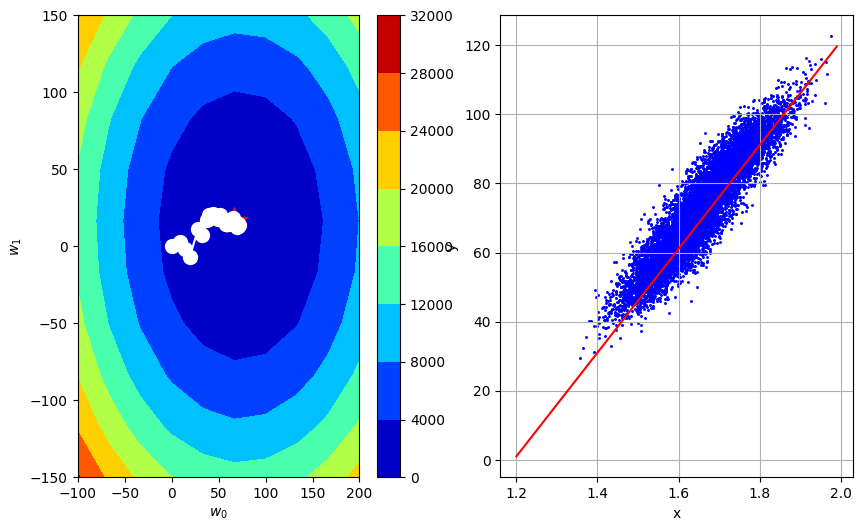

In [96]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


#interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))
interact(plot_figure, n_iter=IntSlider(min=50, max=50))

# 5. Effect of Outliers and MAE Cost Function

In [119]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=True, add_outlier=True)

x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [120]:
y.shape, tx.shape

((202,), (202, 2))

In [121]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/499: loss=2869.8351145358524, w0=51.847464098448484, w1=7.724426406192441
GD iter. 1/499: loss=318.282124701595, w0=67.401703327983, w1=10.041754328050121
GD iter. 2/499: loss=88.6423556165126, w0=72.06797509684336, w1=10.736952704607413
GD iter. 3/499: loss=67.97477639885521, w0=73.46785662750146, w1=10.945512217574594
GD iter. 4/499: loss=66.11469426926604, w0=73.88782108669889, w1=11.00808007146475
GD iter. 5/499: loss=65.94728687760302, w0=74.01381042445813, w1=11.026850427631796
GD iter. 6/499: loss=65.93222021235334, w0=74.05160722578589, w1=11.03248153448191
GD iter. 7/499: loss=65.93086421248087, w0=74.06294626618423, w1=11.034170866536943
GD iter. 8/499: loss=65.93074217249236, w0=74.06634797830372, w1=11.034677666153454
GD iter. 9/499: loss=65.93073118889338, w0=74.06736849193958, w1=11.034829706038407
GD iter. 10/499: loss=65.93073020036948, w0=74.06767464603033, w1=11.034875318003893
GD iter. 11/499: loss=65.93073011140233, w0=74.06776649225756, w1=11.03488900159

interactive(children=(IntSlider(value=500, description='n_iter', max=500, min=500), Output()), _dom_classes=('…

<function __main__.plot_figure(n_iter)>

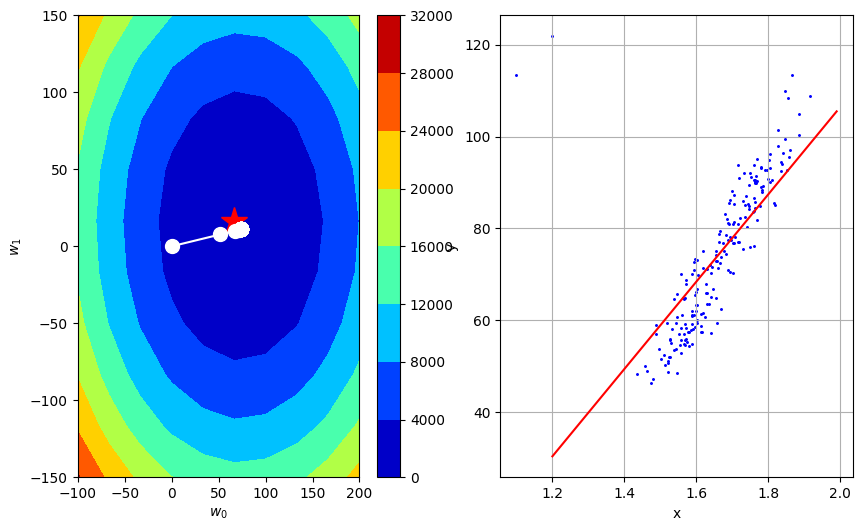

In [122]:
# Time Visualization
from ipywidgets import IntSlider, interact

def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


#interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))
interact(plot_figure, n_iter=IntSlider(min=500, max=500)) # NOTE: you can see two outliers (blue dots) on top left in the right plot

# 6. Subgradient descent

In [123]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    N = tx.shape[0] # total samples
    e = y - (tx @ w) # error vector
    # NOTE: to see derivation for subgrad of MAE, see lecture2a_optimization (pg-17) in notability
    subgrad = (-1/N) * (tx.T @ np.sign(e)) # subgradient. NOTE: np.sign(e) converts value in vector 'e' into a vector of their signs i-e np.sign(e) --> N x 1 vector still
    return subgrad, e # also returning 'e' anyways


In [124]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):

        grad, e = compute_subgradient_mae(y, tx, w)
        loss = np.mean(np.abs(e)) # MAE = 1/N .(sum of all |e|)
        w = w - gamma*grad

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [125]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=74.06780585492638, w0=0.7, w1=8.756471895211877e-16
SubGD iter. 1/499: loss=73.36780585492637, w0=1.4, w1=1.7512943790423754e-15
SubGD iter. 2/499: loss=72.66780585492637, w0=2.0999999999999996, w1=2.626941568563563e-15
SubGD iter. 3/499: loss=71.96780585492637, w0=2.8, w1=3.502588758084751e-15
SubGD iter. 4/499: loss=71.26780585492638, w0=3.5, w1=4.378235947605939e-15
SubGD iter. 5/499: loss=70.56780585492638, w0=4.2, w1=5.253883137127127e-15
SubGD iter. 6/499: loss=69.86780585492637, w0=4.9, w1=6.1295303266483146e-15
SubGD iter. 7/499: loss=69.16780585492639, w0=5.6000000000000005, w1=7.0051775161695025e-15
SubGD iter. 8/499: loss=68.46780585492638, w0=6.300000000000001, w1=7.88082470569069e-15
SubGD iter. 9/499: loss=67.76780585492638, w0=7.000000000000001, w1=8.756471895211878e-15
SubGD iter. 10/499: loss=67.06780585492638, w0=7.700000000000001, w1=9.632119084733065e-15
SubGD iter. 11/499: loss=66.36780585492637, w0=8.4, w1=1.0507766274254253e-14
SubGD iter.

interactive(children=(IntSlider(value=499, description='n_iter', max=500, min=499), Output()), _dom_classes=('…

<function __main__.plot_figure(n_iter)>

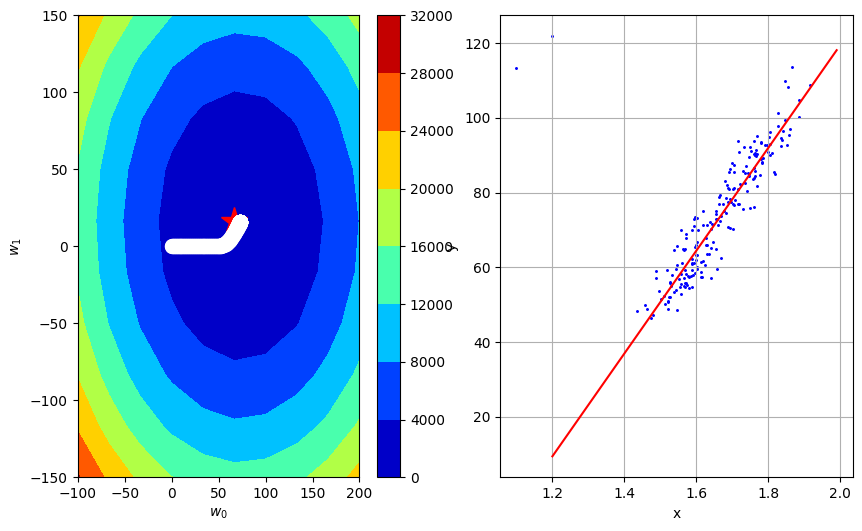

In [126]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


#interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))
interact(plot_figure, n_iter=IntSlider(min=499, max=500))

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [127]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # get a single random batch
        for y_batch, tx_batch in batch_iter(y, tx, batch_size, num_batches=1, shuffle= True): 
            grad, e = compute_subgradient_mae(y_batch, tx_batch, w)
            loss = np.mean(np.abs(e)) # MAE
            w = w - gamma*grad

            # store w and loss
            ws.append(w)
            losses.append(loss)

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [128]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=109.81967768391841, w0=0.7, w1=1.125129960130307
SubSGD iter. 1/499: loss=77.63850357954365, w0=1.4, w1=1.2684605507248234
SubSGD iter. 2/499: loss=85.46907097104574, w0=2.0999999999999996, w1=1.5465875195265113
SubSGD iter. 3/499: loss=58.05334458841928, w0=2.8, w1=1.123348094753997
SubSGD iter. 4/499: loss=94.82215026849467, w0=3.5, w1=2.2416583153654788
SubSGD iter. 5/499: loss=77.6386978521639, w0=4.2, w1=2.62019809872221
SubSGD iter. 6/499: loss=58.31012891876737, w0=4.9, w1=1.766351828296941
SubSGD iter. 7/499: loss=61.270639908219145, w0=5.6000000000000005, w1=1.1933417452823174
SubSGD iter. 8/499: loss=60.60561909167183, w0=6.300000000000001, w1=0.992592208233066
SubSGD iter. 9/499: loss=54.23031593155565, w0=7.000000000000001, w1=-0.03433998935946758
SubSGD iter. 10/499: loss=68.14298043526527, w0=7.700000000000001, w1=0.07596004410132404
SubSGD iter. 11/499: loss=81.23325914644, w0=8.4, w1=0.8009802341821282
SubSGD iter. 12/499: loss=65.44800335371968

interactive(children=(IntSlider(value=499, description='n_iter', max=500, min=499), Output()), _dom_classes=('…

<function __main__.plot_figure(n_iter)>

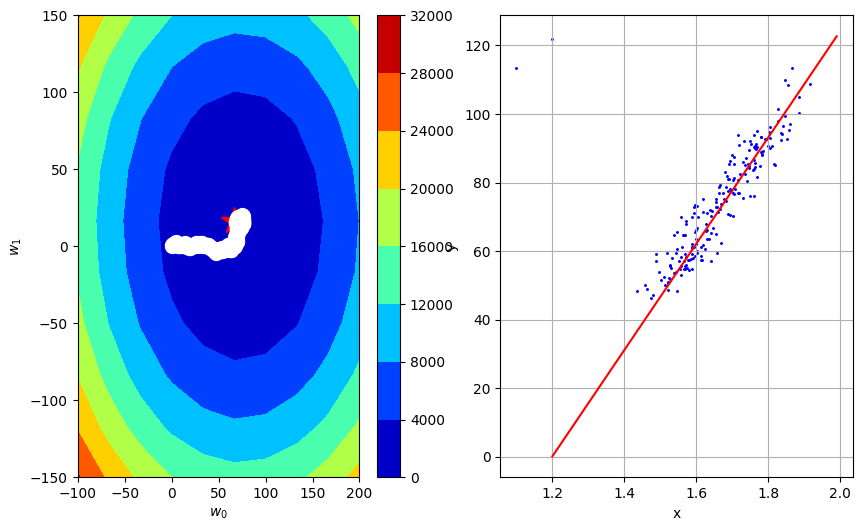

In [129]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


#interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))
interact(plot_figure, n_iter=IntSlider(min=499, max=500))

Discussion:
- Fit using MAE is better (just visually compare plots for the MAE above with the one for MSE in Section.5) --> red line is more close to the data
- with MSE: loss=65.93, w0=74.06, w1=11.03 (Section 5.)
- with MAE: loss=1.18, w0=71.40, w1=18.90 (above)
- MAE's loss is much smaller (obviosly, since it isn't a squared loss --> outliers explode the loss in MSE due to squaring)


# With **MSE** (copied from Section.5)

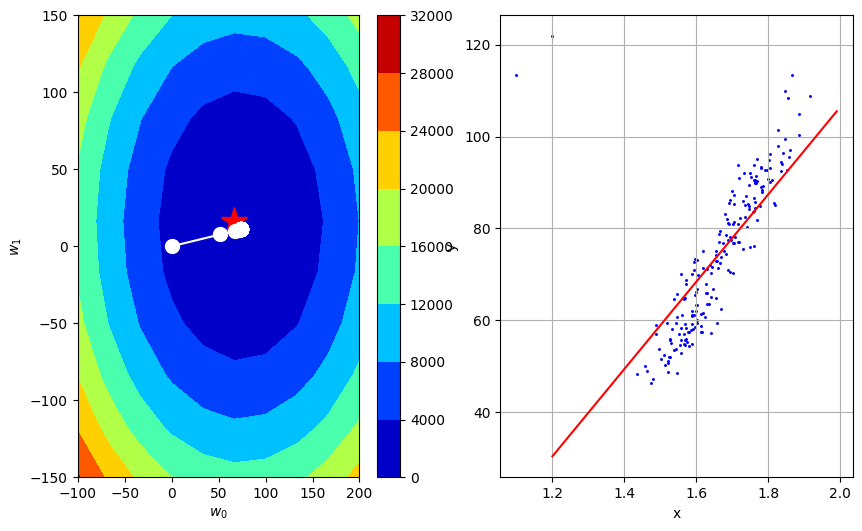